# AutoBot — Scorer Model Training (Qwen2.5-1.5B + LoRA SEQ_CLS)

**Model**: Qwen2.5-1.5B-Instruct with LoRA adapter for 3-class sequence classification

**Task**: Predict bottleneck risk band (0=low, 1=medium, 2=high) from GitHub issue snapshots

**Hardware**: A100 80GB GPU (Colab)

**Training specs** (from AutoBot Ref Doc):
- LoRA r=16, alpha=32, targets: q_proj, v_proj, k_proj, o_proj
- Epochs: 4, Batch: 16, LR: 2e-4, Max seq: 1536 tokens
- 3x loss weight on high band (class 2) to handle imbalance
- days_open jitter ±3 for generalization

## 1. Install Dependencies

In [1]:
!pip install -q transformers==4.46.3 peft==0.13.2 datasets accelerate bitsandbytes trl
!pip install -q scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.0/348.0 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 43.6 MB/s eta 0:00:00


## 2. Upload Data

Upload `train.jsonl`, `val.jsonl`, `test.jsonl` from `labelling/data/labeled/scorer/` to Colab.

Option A — Google Drive mount (recommended for large files):
```python
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/autobot'  # adjust path
```

Option B — Direct upload:

In [2]:
import os

# --- Choose one option ---

# Option A: Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/autobot'  # <-- adjust to your path

# Option B: Direct upload (uncomment below, comment out Option A)
# from google.colab import files
# uploaded = files.upload()  # upload train.jsonl, val.jsonl, test.jsonl
# DATA_DIR = '/content'

print(f"Data dir: {DATA_DIR}")
print(os.listdir(DATA_DIR))

Mounted at /content/drive
Data dir: /content/drive/MyDrive/autobot
['test.jsonl', 'val.jsonl', 'train.jsonl', 'scorer', '.ipynb_checkpoints']


## 3. Load & Prepare Dataset

In [4]:
import json
import random
from collections import Counter

random.seed(42)

def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    return records

train_raw = load_jsonl(os.path.join(DATA_DIR, 'train.jsonl'))
val_raw = load_jsonl(os.path.join(DATA_DIR, 'val.jsonl'))
test_raw = load_jsonl(os.path.join(DATA_DIR, 'test.jsonl'))

print(f"Train: {len(train_raw)}, Val: {len(val_raw)}, Test: {len(test_raw)}")
print(f"Train band dist: {Counter(r['label']['band_name'] for r in train_raw)}")

Train: 3400, Val: 457, Test: 411
Train band dist: Counter({'medium': 1522, 'low': 1342, 'high': 536})


In [5]:
def apply_days_open_jitter(text: str, jitter_range: int = 3) -> str:
    """Apply ±3 day jitter to DAYS_OPEN in the prompt string.

    Prevents the model from learning a step function on exact T+7/T+15/etc values.
    Label stays unchanged — only the prompt number varies.
    """
    import re
    match = re.search(r'DAYS_OPEN: (\d+)', text)
    if match:
        original = int(match.group(1))
        jittered = max(1, original + random.randint(-jitter_range, jitter_range))
        text = text.replace(f'DAYS_OPEN: {original}', f'DAYS_OPEN: {jittered}')
    return text


# ── Qwen Scorer System Prompt (Section 5A.5) ──────────────────────────
# This MUST match exactly what is used at inference time.
# Defines the task, output format, and project calibration context.
SYSTEM_PROMPT = (
    'You are a bottleneck risk scorer for GitHub issues. '
    'Given an issue snapshot, output a single integer class 0-2 '
    'where 0=Low risk, 1=Medium, 2=High. '
    'Output the class number only, nothing else.\n'
    'PROJECT: apache/airflow | P50=1d P75=5d P90=22d P95=44d'
)

import re

print(f'System prompt ({len(SYSTEM_PROMPT)} chars):\n{SYSTEM_PROMPT}')

System prompt (246 chars):
You are a bottleneck risk scorer for GitHub issues. Given an issue snapshot, output a single integer class 0-2 where 0=Low risk, 1=Medium, 2=High. Output the class number only, nothing else.
PROJECT: apache/airflow | P50=1d P75=5d P90=22d P95=44d


## 4. Load Tokenizer & Model

In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
NUM_LABELS = 3  # low, medium, high
MAX_SEQ_LEN = 1536

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)

# Qwen uses eos_token as pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    torch_dtype=torch.bfloat16,
    trust_remote_code=True,
)
model.config.pad_token_id = tokenizer.pad_token_id

print(f"Model loaded: {MODEL_ID}")
print(f"Parameters: {model.num_parameters():,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-1.5B-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Parameters: 1,543,718,912


## 4b. Prepare Data with Chat Template

In [7]:
def prepare_examples(records, apply_jitter=False):
    """Convert raw JSONL records to (text, label) pairs.

    Applies Qwen chat template with system prompt so training format
    matches inference format exactly. Strips SNAPSHOT_TIER from input
    (not available at inference).
    """
    examples = []
    for r in records:
        text = r['input']
        label = r['label']['band']  # 0=low, 1=medium, 2=high

        # Strip SNAPSHOT_TIER — not available at inference
        text = re.sub(r'\| SNAPSHOT_TIER: T\+\d+\s*', '', text)

        if apply_jitter:
            text = apply_days_open_jitter(text)

        # Apply Qwen chat template with system prompt
        # This ensures training format == inference format
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': text},
        ]
        formatted = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        examples.append({'text': formatted, 'label': label})
    return examples


train_data = prepare_examples(train_raw, apply_jitter=True)
val_data = prepare_examples(val_raw, apply_jitter=False)
test_data = prepare_examples(test_raw, apply_jitter=False)

print(f'Sample input (first 300 chars):\n{train_data[0]["text"][:300]}')
print(f'\nSample label: {train_data[0]["label"]}')

Sample input (first 300 chars):
<|im_start|>system
You are a bottleneck risk scorer for GitHub issues. Given an issue snapshot, output a single integer class 0-2 where 0=Low risk, 1=Medium, 2=High. Output the class number only, nothing else.
PROJECT: apache/airflow | P50=1d P75=5d P90=22d P95=44d<|im_end|>
<|im_start|>user
PROJECT

Sample label: 0


## 5. Apply LoRA

In [8]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    bias="none",
)

model = get_peft_model(model, lora_config)
model.gradient_checkpointing_enable()  # save VRAM on A100
model.print_trainable_parameters()

trainable params: 4,362,752 || all params: 1,548,081,664 || trainable%: 0.2818


## 6. Tokenize Dataset

In [9]:
from datasets import Dataset

def tokenize_fn(examples):
    tokens = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LEN,
        padding='max_length',
    )
    tokens['labels'] = examples['label']
    return tokens

train_ds = Dataset.from_list(train_data).map(tokenize_fn, batched=True, remove_columns=['text'])
val_ds = Dataset.from_list(val_data).map(tokenize_fn, batched=True, remove_columns=['text'])
test_ds = Dataset.from_list(test_data).map(tokenize_fn, batched=True, remove_columns=['text'])

train_ds.set_format('torch')
val_ds.set_format('torch')
test_ds.set_format('torch')

# Check token lengths
sample_lens = [len(tokenizer.encode(d['text'], truncation=False)) for d in train_data[:100]]
print(f"Token length stats (first 100): min={min(sample_lens)}, max={max(sample_lens)}, "
      f"mean={sum(sample_lens)/len(sample_lens):.0f}")
print(f"Exceeding {MAX_SEQ_LEN}: {sum(1 for l in sample_lens if l > MAX_SEQ_LEN)}/100")

Map:   0%|          | 0/3400 [00:00<?, ? examples/s]

Map:   0%|          | 0/457 [00:00<?, ? examples/s]

Map:   0%|          | 0/411 [00:00<?, ? examples/s]

Token length stats (first 100): min=233, max=1414, mean=690
Exceeding 1536: 0/100


## 7. Training Setup

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from transformers import Trainer, TrainingArguments

# --- Class weights: 3x on high band ---
# Band distribution: low ~39.5%, medium ~44.8%, high ~15.8%
# Apply 3x weight to high to get ~1,608 effective examples
class_weights = torch.tensor([1.0, 1.0, 3.0], dtype=torch.float32)


class WeightedTrainer(Trainer):
    """Trainer with per-class loss weighting."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        weights = class_weights.to(logits.device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc        = accuracy_score(labels, preds)
    f1_macro   = f1_score(labels, preds, average='macro')
    f1_per     = f1_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)
    prec_per   = precision_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)
    recall_per = recall_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)

    return {
        # Overall
        'accuracy':       acc,
        'f1_macro':       f1_macro,
        # High band — primary go/no-go signals
        'recall_high':    recall_per[2],   # #1 priority — must be > 0.70
        'f1_high':        f1_per[2],       # #2 priority — must be > 0.65
        'precision_high': prec_per[2],
        # Medium band
        'f1_medium':      f1_per[1],
        'recall_medium':  recall_per[1],
        # Low band
        'precision_low':  prec_per[0],     # must stay > 0.70
        'f1_low':         f1_per[0],
    }


OUTPUT_DIR = '/content/scorer_checkpoints'

# Drive path for persistent storage
DRIVE_DIR = '/content/drive/MyDrive/autobot/scorer'
DRIVE_PLOTS = f'{DRIVE_DIR}/plots'
os.makedirs(DRIVE_PLOTS, exist_ok=True)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_ratio=0.1,
    weight_decay=0.01,
    bf16=True,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    logging_steps=50,
    report_to='none',
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print(f"Training config: {training_args.num_train_epochs} epochs, "
      f"batch={training_args.per_device_train_batch_size}, "
      f"lr={training_args.learning_rate}, max_seq={MAX_SEQ_LEN}")
print(f"Class weights: {class_weights.tolist()} (3x on high band)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config: 4 epochs, batch=16, lr=0.0002, max_seq=1536
Class weights: [1.0, 1.0, 3.0] (3x on high band)


## 8. Train

In [11]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Recall High,F1 High,Precision High,F1 Medium,Recall Medium,Precision Low,F1 Low
1,1.066741,1.159887,0.466083,0.365318,0.078125,0.135135,0.500000,0.551181,0.669856,0.459459,0.409639
2,0.587840,0.521851,0.748359,0.725125,0.937500,0.621762,0.465116,0.664723,0.545455,0.865979,0.888889
3,0.340434,0.349861,0.853392,0.830720,0.937500,0.722892,0.588235,0.827763,0.770335,0.965714,0.941504
4,0.228775,0.313559,0.877462,0.853695,0.812500,0.759124,0.712329,0.866029,0.866029,0.960000,0.935933


TrainOutput(global_step=852, training_loss=0.7473069141168549, metrics={'train_runtime': 1820.1075, 'train_samples_per_second': 7.472, 'train_steps_per_second': 0.468, 'total_flos': 1.647823414099968e+17, 'train_loss': 0.7473069141168549, 'epoch': 4.0})

## 9. Evaluate on Test Set

In [12]:
# Eval on test set
test_results = trainer.evaluate(test_ds)
print("\nTest Results:")
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}")

# Detailed classification report
preds_output = trainer.predict(test_ds)
preds = np.argmax(preds_output.predictions, axis=-1)
labels = preds_output.label_ids

print("\nClassification Report:")
print(classification_report(
    labels, preds,
    target_names=['low', 'medium', 'high'],
    digits=3,
))


Test Results:
  eval_loss: 0.2545
  eval_accuracy: 0.8954
  eval_f1_macro: 0.8789
  eval_recall_high: 0.8462
  eval_f1_high: 0.8088
  eval_precision_high: 0.7746
  eval_f1_medium: 0.8796
  eval_recall_medium: 0.8579
  eval_precision_low: 0.9398
  eval_f1_low: 0.9483
  eval_runtime: 14.7060
  eval_samples_per_second: 27.9480
  eval_steps_per_second: 1.7680
  epoch: 4.0000

Classification Report:
              precision    recall  f1-score   support

         low      0.940     0.957     0.948       163
      medium      0.902     0.858     0.880       183
        high      0.775     0.846     0.809        65

    accuracy                          0.895       411
   macro avg      0.872     0.887     0.879       411
weighted avg      0.897     0.895     0.896       411



## 10. Visualizations (Presentation-Ready)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

BAND_LABELS = ['low', 'medium', 'high']
COLORS = ['#4CAF50', '#FFC107', '#F44336']  # green, amber, red

# Compute all per-band metrics for plots
per_prec = precision_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)
per_rec = recall_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)
per_f1 = f1_score(labels, preds, average=None, labels=[0,1,2], zero_division=0)

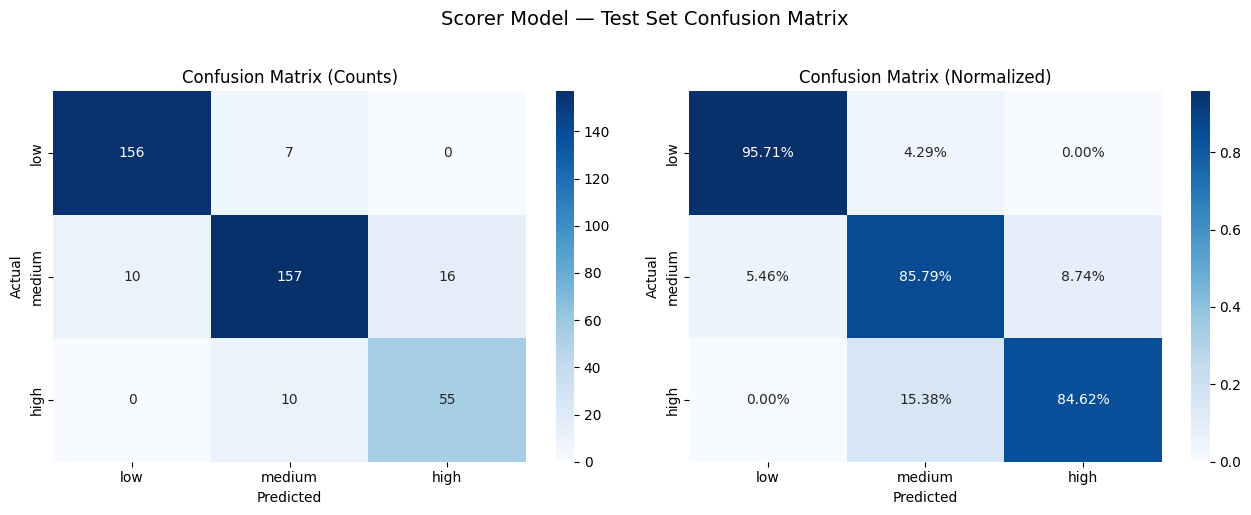

In [14]:
# --- 10a. Confusion Matrix (normalized + raw counts) ---
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=BAND_LABELS, yticklabels=BAND_LABELS, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix (Counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=BAND_LABELS, yticklabels=BAND_LABELS, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix (Normalized)')

fig.suptitle('Scorer Model — Test Set Confusion Matrix', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{DRIVE_PLOTS}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

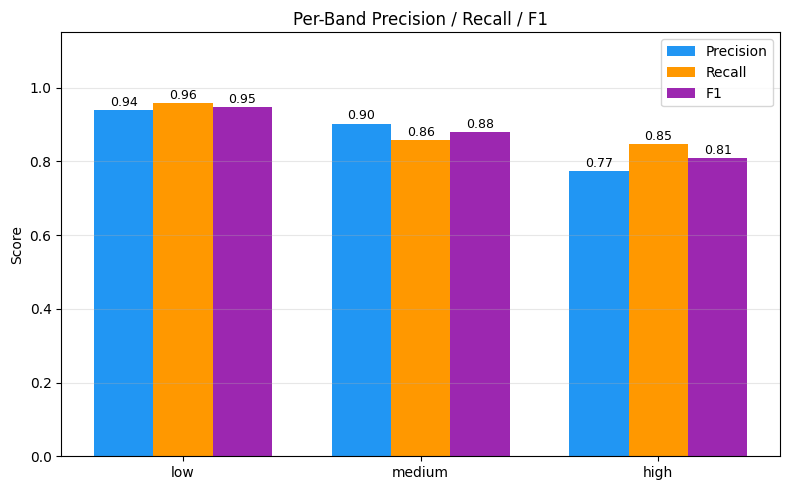

In [15]:
# --- 10b. Per-Band Precision / Recall / F1 (grouped bar chart) ---
x = np.arange(len(BAND_LABELS))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width, per_prec, width, label='Precision', color='#2196F3')
bars2 = ax.bar(x, per_rec, width, label='Recall', color='#FF9800')
bars3 = ax.bar(x + width, per_f1, width, label='F1', color='#9C27B0')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(BAND_LABELS)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Band Precision / Recall / F1')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_PLOTS}/per_band_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

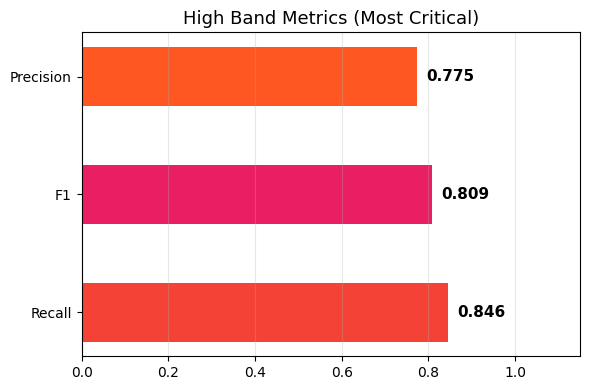

In [16]:
# --- 10c. High Band Focus — Recall is #1 priority ---
fig, ax = plt.subplots(figsize=(6, 4))
metrics = ['Recall', 'F1', 'Precision']
values = [per_rec[2], per_f1[2], per_prec[2]]
colors_h = ['#F44336', '#E91E63', '#FF5722']

bars = ax.barh(metrics, values, color=colors_h, height=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlim(0, 1.15)
ax.set_title('High Band Metrics (Most Critical)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_PLOTS}/high_band_focus.png', dpi=150, bbox_inches='tight')
plt.show()

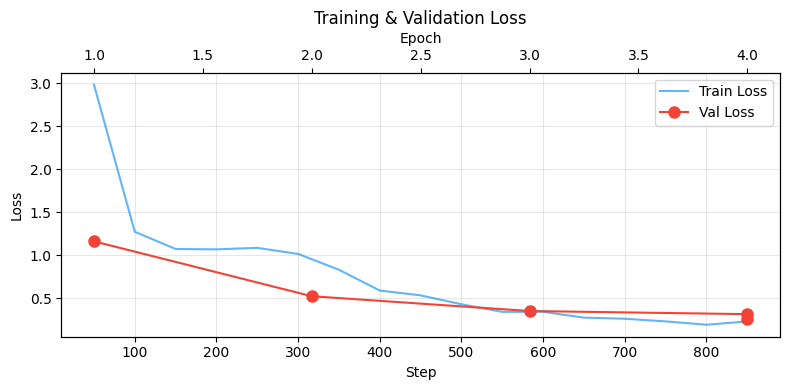

In [17]:
# --- 10d. Training Loss Curve ---
log_history = trainer.state.log_history
train_steps = [h['step'] for h in log_history if 'loss' in h]
train_loss = [h['loss'] for h in log_history if 'loss' in h]
eval_epochs = [h['epoch'] for h in log_history if 'eval_loss' in h]
eval_loss = [h['eval_loss'] for h in log_history if 'eval_loss' in h]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(train_steps, train_loss, alpha=0.7, label='Train Loss', color='#2196F3')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')

ax2 = ax1.twiny()
ax2.plot(eval_epochs, eval_loss, 'o-', color='#F44336', label='Val Loss', markersize=8)
ax2.set_xlabel('Epoch')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('Training & Validation Loss')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DRIVE_PLOTS}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# --- 10e. Summary Metrics Table (copy-paste for slides) ---
print('=' * 50)
print('SCORER MODEL — TEST SET RESULTS')
print('=' * 50)
print(f"{'Metric':<25} {'Value':>10}")
print('-' * 36)
print(f"{'Accuracy':<25} {accuracy_score(labels, preds):>10.3f}")
print(f"{'F1 Macro':<25} {f1_score(labels, preds, average='macro'):>10.3f}")
print(f"{'F1 Weighted':<25} {f1_score(labels, preds, average='weighted'):>10.3f}")
print('-' * 36)
print(f"{'High Recall ★':<25} {per_rec[2]:>10.3f}")
print(f"{'High F1 ★':<25} {per_f1[2]:>10.3f}")
print(f"{'High Precision':<25} {per_prec[2]:>10.3f}")
print('-' * 36)
print(f"{'Medium Recall':<25} {per_rec[1]:>10.3f}")
print(f"{'Medium F1':<25} {per_f1[1]:>10.3f}")
print('-' * 36)
print(f"{'Low Precision':<25} {per_prec[0]:>10.3f}")
print(f"{'Low F1':<25} {per_f1[0]:>10.3f}")
print('=' * 50)
print('\nAll outputs saved to Google Drive:')
print(f'  Plots:   {DRIVE_PLOTS}/')
print(f'  Adapter: {DRIVE_DIR}/scorer_lora_adapter/')

# Save metrics as JSON for programmatic access
metrics_dict = {
    'accuracy': float(accuracy_score(labels, preds)),
    'f1_macro': float(f1_score(labels, preds, average='macro')),
    'f1_weighted': float(f1_score(labels, preds, average='weighted')),
    'recall_high': float(per_rec[2]),
    'f1_high': float(per_f1[2]),
    'precision_high': float(per_prec[2]),
    'recall_medium': float(per_rec[1]),
    'f1_medium': float(per_f1[1]),
    'precision_low': float(per_prec[0]),
    'f1_low': float(per_f1[0]),
}
with open(f'{DRIVE_DIR}/test_metrics.json', 'w') as f:
    json.dump(metrics_dict, f, indent=2)
print(f'  Metrics: {DRIVE_DIR}/test_metrics.json')

SCORER MODEL — TEST SET RESULTS
Metric                         Value
------------------------------------
Accuracy                       0.895
F1 Macro                       0.879
F1 Weighted                    0.896
------------------------------------
High Recall ★                  0.846
High F1 ★                      0.809
High Precision                 0.775
------------------------------------
Medium Recall                  0.858
Medium F1                      0.880
------------------------------------
Low Precision                  0.940
Low F1                         0.948

All outputs saved to Google Drive:
  Plots:   /content/drive/MyDrive/autobot/scorer/plots/
  Adapter: /content/drive/MyDrive/autobot/scorer/scorer_lora_adapter/
  Metrics: /content/drive/MyDrive/autobot/scorer/test_metrics.json


## 11. Save LoRA Adapter

In [19]:
# --- 11a. Save LoRA adapter (lightweight, for further fine-tuning) ---
ADAPTER_DIR = '/content/scorer_lora_adapter'

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print(f"LoRA adapter saved to {ADAPTER_DIR}")
print(f"Files: {os.listdir(ADAPTER_DIR)}")

# Save to Drive
DRIVE_ADAPTER = f'{DRIVE_DIR}/scorer_lora_adapter'
os.makedirs(DRIVE_ADAPTER, exist_ok=True)
model.save_pretrained(DRIVE_ADAPTER)
tokenizer.save_pretrained(DRIVE_ADAPTER)
print(f"Also saved to Drive: {DRIVE_ADAPTER}")

# --- 11b. Merge LoRA into base and save full model (for Vertex AI) ---
merged_model = model.merge_and_unload()

MERGED_DIR = f'{DRIVE_DIR}/scorer_merged_model'
os.makedirs(MERGED_DIR, exist_ok=True)

merged_model.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

# Save system prompt and serving config
serving_config = {
    'model_id': MODEL_ID,
    'num_labels': NUM_LABELS,
    'max_seq_len': MAX_SEQ_LEN,
    'band_names': ['low', 'medium', 'high'],
    'band_scores': [0.175, 0.50, 0.825],
    'system_prompt': SYSTEM_PROMPT,
}
with open(f'{MERGED_DIR}/serving_config.json', 'w') as f:
    json.dump(serving_config, f, indent=2)

print(f"\nMerged model saved to: {MERGED_DIR}")
print(f"Files: {os.listdir(MERGED_DIR)}")
print(f"\nVertex AI deployment needs this directory:")
print(f"  - model.safetensors (full merged weights)")
print(f"  - config.json (model architecture)")
print(f"  - tokenizer files")
print(f"  - serving_config.json (system prompt, band config)")


LoRA adapter saved to /content/scorer_lora_adapter
Files: ['tokenizer_config.json', 'adapter_model.safetensors', 'README.md', 'chat_template.jinja', 'adapter_config.json', 'tokenizer.json']
Also saved to Drive: /content/drive/MyDrive/autobot/scorer/scorer_lora_adapter


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Merged model saved to: /content/drive/MyDrive/autobot/scorer/scorer_merged_model
Files: ['config.json', 'model.safetensors', 'chat_template.jinja', 'tokenizer_config.json', 'tokenizer.json', 'serving_config.json']

Vertex AI deployment needs this directory:
  - model.safetensors (full merged weights)
  - config.json (model architecture)
  - tokenizer files
  - serving_config.json (system prompt, band config)


## 12. Inference Example

How to load and use the trained model for scoring new issues.

In [21]:
from peft import PeftModel

# --- Load for inference ---
# base_model = AutoModelForSequenceClassification.from_pretrained(
#     MODEL_ID, num_labels=3, torch_dtype=torch.bfloat16, trust_remote_code=True
# )
# model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
# model.eval()

BAND_NAMES = ['low', 'medium', 'high']
BAND_SCORES = [0.175, 0.50, 0.825]  # midpoints of each band


def score_issue(text: str) -> dict:
    """Score a single issue snapshot.

    Returns: {band: int, band_name: str, score: float, probabilities: list}
    """
    model.eval()  # ensure dropout is off for consistent inference
    # Apply same chat template as training
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': text},
    ]
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    inputs = tokenizer(formatted, return_tensors='pt', truncation=True,
                       max_length=MAX_SEQ_LEN, padding=True).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().tolist()
    pred_band = int(torch.argmax(logits, dim=-1).item())
    return {
        'band': pred_band,
        'band_name': BAND_NAMES[pred_band],
        'score': BAND_SCORES[pred_band],
        'probabilities': {name: round(p, 4) for name, p in zip(BAND_NAMES, probs)},
    }


# Test on 100 random examples from test set
import random
random.seed(42)
sample_indices = random.sample(range(len(test_data)), min(100, len(test_data)))

correct = 0
for i in sample_indices:
    result = score_issue(test_data[i]['text'])
    actual = test_data[i]['label']
    match = "✓" if result['band'] == actual else "✗"
    if result['band'] == actual:
        correct += 1
    print(f"{match} Actual: {BAND_NAMES[actual]:8s} | Predicted: {result['band_name']:8s} | "
          f"Probs: {result['probabilities']}")

print(f"\n{'='*50}")
print(f"Inference accuracy on 100 samples: {correct}/100 ({correct}%)")


✗ Actual: medium   | Predicted: high     | Probs: {'low': 0.001, 'medium': 0.3399, 'high': 0.6591}
✓ Actual: low      | Predicted: low      | Probs: {'low': 0.9966, 'medium': 0.0034, 'high': 0.0}
✓ Actual: medium   | Predicted: medium   | Probs: {'low': 0.0019, 'medium': 0.9619, 'high': 0.0362}
✓ Actual: medium   | Predicted: medium   | Probs: {'low': 0.0028, 'medium': 0.8321, 'high': 0.1651}
✓ Actual: low      | Predicted: low      | Probs: {'low': 0.9559, 'medium': 0.044, 'high': 0.0001}
✗ Actual: medium   | Predicted: high     | Probs: {'low': 0.0006, 'medium': 0.0753, 'high': 0.9242}
✓ Actual: medium   | Predicted: medium   | Probs: {'low': 0.0224, 'medium': 0.9319, 'high': 0.0457}
✓ Actual: medium   | Predicted: medium   | Probs: {'low': 0.0157, 'medium': 0.7643, 'high': 0.22}
✗ Actual: low      | Predicted: medium   | Probs: {'low': 0.2971, 'medium': 0.6935, 'high': 0.0094}
✓ Actual: medium   | Predicted: medium   | Probs: {'low': 0.0075, 'medium': 0.5166, 'high': 0.4759}
✓ Actua